# DoriaNET Project - Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
**Course:** Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:**  
**Task:**  
**Approach:**

## Setup

In [2]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd DoriaNETProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2156, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 2156 (delta 47), reused 5 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2156/2156), 62.01 MiB | 21.24 MiB/s, done.
Resolving deltas: 100% (1706/1706), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/DoriaNETProject
 data
 DoriaNET.ipynb
'DoriaNET report.pdf'
'main paper. Deep learning for post-hurricane aerial damage assessmentof buildings.pdf'
 README.md


In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

DATA_ROOT = Path('data')
FRAME_DIR = DATA_ROOT / 'FRAME'
MASK_DIR = DATA_ROOT / 'MASK'
JSON_DIR = DATA_ROOT / 'JSON'

DAMAGE_LABELS = {
    0: 'No damage',
    1: 'Minor',
    2: 'Moderate',
    3: 'Severe',
    4: 'Destruction',
    5: 'Under construction / destroyed'
}

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
frame_files = sorted(FRAME_DIR.glob("*.jpg"))
mask_files  = sorted(MASK_DIR.glob("*.jpg"))
json_files  = sorted(JSON_DIR.glob("*.json"))

print(f"FRAME : {len(frame_files):>5} files")
print(f"MASK  : {len(mask_files):>5} files")
print(f"JSON  : {len(json_files):>5} files")

print("\nSample names:")
for f in frame_files[:3]: print("  FRAME:", f.name)
for f in mask_files[:3]:  print("  MASK :", f.name)
for f in json_files[:3]:  print("  JSON :", f.name)

# Spot-check a single frame's resolution (paper says 1280×720)
img = plt.imread(frame_files[0])
print(f'Frame[0] shape: {img.shape}, dtype: {img.dtype}')
img = plt.imread(mask_files[0])
print(f'Mask[0] shape: {img.shape}, dtype: {img.dtype}')

FRAME :   271 files
MASK  :  1458 files
JSON  :   271 files

Sample names:
  FRAME: 1_0373.jpg
  FRAME: 1_0379.jpg
  FRAME: 1_0405.jpg
  MASK : 1_0373_B0XX_0_Level1.jpg
  MASK : 1_0379_B0XX_0_Level0.jpg
  MASK : 1_0379_B0XX_0_Level2.jpg
  JSON : 1_0373.json
  JSON : 1_0379.json
  JSON : 1_0405.json
Frame[0] shape: (720, 1280, 3), dtype: uint8
Mask[0] shape: (720, 1280, 3), dtype: uint8


In [5]:
sample_json = json_files[0]
with open(sample_json) as f:
  sample = json.load(f)

print(f'File: {sample_json.name}')
print(f'Top-level keys: {list(sample.keys())}\n')
print(json.dumps(sample, indent=2)[:2000])

File: 1_0373.json
Top-level keys: ['Frame_Name', 'Buildings', 'Capture date', 'Region', 'Original video link']

{
  "Frame_Name": "FRAME/1_0373.jpg",
  "Buildings": [
    [
      "B004",
      "26.55438, -77.0968",
      "1_0373_B0XX_0_Level1.jpg",
      1,
      1,
      1,
      NaN
    ]
  ],
  "Capture date": "09 September 2019",
  "Region": "Marsh Harbor, Abaco, the bahamas",
  "Original video link": "https://youtu.be/T0GojxvrFm8"
}


In [6]:
# Confirm every building is a 7-element list and inspect field-value distributions
all_buildings = []
for p in json_files:
    with open(p) as f:
        d = json.load(f)
    all_buildings.extend(d["Buildings"])

lengths = {len(b) for b in all_buildings}
print(f"Total buildings: {len(all_buildings)}")
print(f"Distinct row lengths: {lengths}")  # should be {7}

# Field-by-field value distribution for the unknown positions
for i in [3, 4, 5, 6]:
    vals = pd.Series([b[i] for b in all_buildings])
    print(f"\nField [{i}] — dtype: {vals.dtype}, n_unique: {vals.nunique(dropna=False)}, "
          f"NaN count: {vals.isna().sum()}")
    print(vals.value_counts(dropna=False).sort_index().head(10))

# Cross-check field [3] against the mask filename's _LevelN suffix
import re
level_re = re.compile(r"_Level(\d)\.jpg$")
mismatches = 0
for b in all_buildings:
    m = level_re.search(b[2])
    if m and int(m.group(1)) != b[3]:
        mismatches += 1
print(f"\nDamage-vs-filename mismatches: {mismatches} / {len(all_buildings)}")

Total buildings: 1458
Distinct row lengths: {7}

Field [3] — dtype: int64, n_unique: 6, NaN count: 0
0    168
1    264
2    196
3    464
4    258
5    108
Name: count, dtype: int64

Field [4] — dtype: int64, n_unique: 2, NaN count: 0
1    1257
2     201
Name: count, dtype: int64

Field [5] — dtype: int64, n_unique: 3, NaN count: 0
0     328
1    1029
2     101
Name: count, dtype: int64

Field [6] — dtype: float64, n_unique: 1, NaN count: 1458
NaN    1458
Name: count, dtype: int64

Damage-vs-filename mismatches: 0 / 1458


In [7]:
def parse_frame_json(path):
    with open(path) as f:
        d = json.load(f)
    rows = []
    for b in d["Buildings"]:                          # b is a 7-element list
        lat, lon = (float(x) for x in b[1].split(","))
        rows.append({
            "json_file":    path.name,
            "frame_name":   Path(d["Frame_Name"]).name,  # strip "FRAME/" prefix
            "building_id":  b[0],
            "lat":          lat,
            "lon":          lon,
            "mask_name":    b[2],
            "damage":       b[3],
            "stories":      b[4],
            "effort":       b[5],
            "region":       d.get("Region"),
            "capture_date": d.get("Capture date"),
            "video_url":    d.get("Original video link"),
        })
    return rows

records = [r for p in json_files for r in parse_frame_json(p)]
df = pd.DataFrame(records)

print(f"Total building instances: {len(df)}")
print(f"Distinct frames in JSON : {df['frame_name'].nunique()}")
print(f"Distinct mask filenames : {df['mask_name'].nunique()}")
print(f"Distinct building IDs   : {df['building_id'].nunique()}")
df.head()

Total building instances: 1458
Distinct frames in JSON : 271
Distinct mask filenames : 1458
Distinct building IDs   : 147


,json_file,frame_name,building_id,lat,lon,mask_name,damage,stories,effort,region,capture_date,video_url
0,1_0373.json,1_0373.jpg,B004,26.55438,-77.09680,1_0373_B0XX_0_Level1.jpg,1,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
1,1_0379.json,1_0379.jpg,B001,26.55511,-77.10044,1_0379_B0XX_0_Level0.jpg,0,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
2,1_0379.json,1_0379.jpg,B002,26.55516,-77.09986,1_0379_B0XX_0_Level2.jpg,2,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
3,1_0379.json,1_0379.jpg,B003,26.55452,-77.09913,1_0379_B0XX_0_Level3.jpg,3,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8
4,1_0405.json,1_0405.jpg,B001,26.55511,-77.10044,1_0405_B0XX_0_Level0.jpg,0,1,1,"Marsh Harbor, Abaco, the bahamas",09 September 2019,https://youtu.be/T0GojxvrFm8


In [8]:
# How are the 1458 instances distributed across (frame prefix, building_id)?
prefix = df["frame_name"].str.extract(r"^(\d+)_")[0]
print("Frame name prefixes (likely video IDs):")
print(prefix.value_counts())

# Does (lat, lon) round-tripped to 5 decimals give us 147 unique values?
df["coord_key"] = df.apply(lambda r: (round(r["lat"], 5), round(r["lon"], 5)), axis=1)
print(f"\nDistinct (lat, lon) keys      : {df['coord_key'].nunique()}")
print(f"Distinct building_id alone    : {df['building_id'].nunique()}")
print(f"Distinct (prefix, building_id): {df.groupby([prefix, 'building_id']).ngroups}")

Frame name prefixes (likely video IDs):
0
2    755
3    535
1    168
Name: count, dtype: int64

Distinct (lat, lon) keys      : 147
Distinct building_id alone    : 147
Distinct (prefix, building_id): 163


In [9]:
print(df.groupby("building_id").size().describe())

count    147.000000
mean       9.918367
std        7.905703
min        1.000000
25%        4.000000
50%        8.000000
75%       13.000000
max       39.000000
dtype: float64


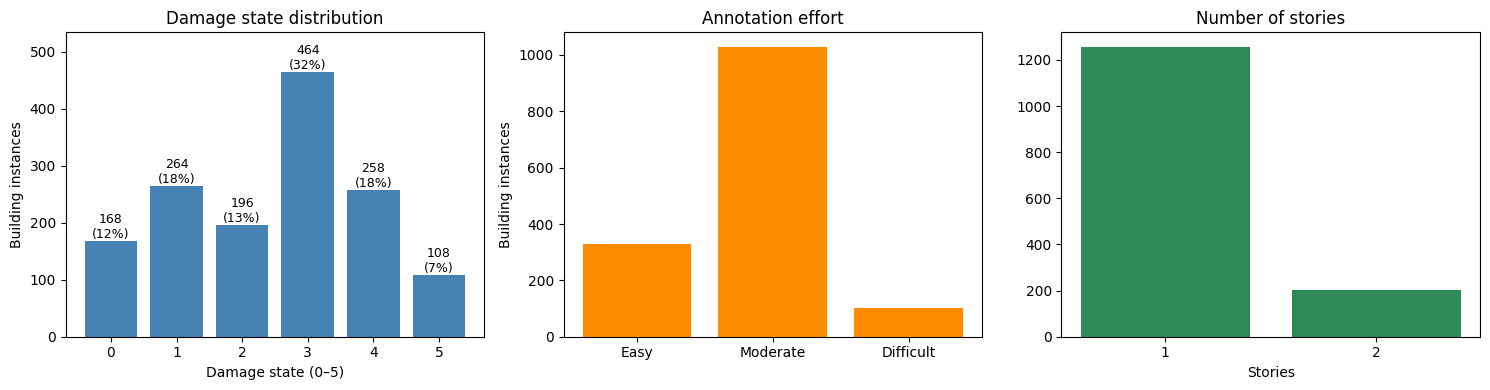


Damage × Effort cross-tab (counts):
effort    0     1    2   All
damage                      
0        26   126   16   168
1        65   193    6   264
2        42   134   20   196
3       133   300   31   464
4        50   195   13   258
5        12    81   15   108
All     328  1029  101  1458

Buildings per frame — mean: 5.4, median: 5, min: 1, max: 17


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Damage state
dmg_counts = df["damage"].value_counts().sort_index()
axes[0].bar(dmg_counts.index.astype(str), dmg_counts.values, color="steelblue")
axes[0].set_title("Damage state distribution")
axes[0].set_xlabel("Damage state (0–5)"); axes[0].set_ylabel("Building instances")
axes[0].set_ylim(0, dmg_counts.max() * 1.15)
for i, v in enumerate(dmg_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({100*v/len(df):.0f}%)", ha="center", fontsize=9)

# Annotation effort
eff_counts = df["effort"].value_counts().sort_index()
eff_labels = {0: "Easy", 1: "Moderate", 2: "Difficult"}
axes[1].bar([eff_labels.get(i, str(i)) for i in eff_counts.index],
            eff_counts.values, color="darkorange")
axes[1].set_title("Annotation effort"); axes[1].set_ylabel("Building instances")

# Stories
st_counts = df["stories"].value_counts().sort_index()
axes[2].bar(st_counts.index.astype(str), st_counts.values, color="seagreen")
axes[2].set_title("Number of stories"); axes[2].set_xlabel("Stories")

plt.tight_layout(); plt.show()

# Cross-tab: damage × annotation effort (for reporting accuracy stratified by difficulty later)
print("\nDamage × Effort cross-tab (counts):")
print(pd.crosstab(df["damage"], df["effort"], margins=True))

# Buildings per frame
bpf = df.groupby("frame_name").size()
print(f"\nBuildings per frame — mean: {bpf.mean():.1f}, median: {bpf.median():.0f}, "
      f"min: {bpf.min()}, max: {bpf.max()}")

In [11]:
frame_set_disk = {p.name for p in frame_files}
mask_set_disk  = {p.name for p in mask_files}
frame_set_json = set(df["frame_name"].dropna())
mask_set_json  = set(df["mask_name"].dropna())

# (1) Every JSON-referenced frame exists on disk
missing_frames = frame_set_json - frame_set_disk
print(f"JSON frames missing from FRAME/ : {len(missing_frames)}")
if missing_frames: print("  examples:", list(missing_frames)[:5])

# (2) Every JSON-referenced mask exists on disk
missing_masks = mask_set_json - mask_set_disk
print(f"JSON masks  missing from MASK/  : {len(missing_masks)}")
if missing_masks: print("  examples:", list(missing_masks)[:5])

# (3) Orphans (files on disk that nothing references)
orphan_frames = frame_set_disk - frame_set_json
orphan_masks  = mask_set_disk  - mask_set_json
print(f"Orphan frames (on disk, no JSON ref): {len(orphan_frames)}")
print(f"Orphan masks  (on disk, no JSON ref): {len(orphan_masks)}")

# (4) Mask vs frame dimension agreement on a small sample
print("\nDimension check on 5 random masks vs their frames:")
for _, row in df.dropna(subset=["mask_name"]).sample(5, random_state=42).iterrows():
    fp = FRAME_DIR / row["frame_name"]
    mp = MASK_DIR  / row["mask_name"]
    fi = plt.imread(fp)
    mi = plt.imread(mp)
    print(f'  {row['frame_name']:<15} frame {fi.shape} vs mask {mi.shape} match={fi.shape == mi.shape}')

JSON frames missing from FRAME/ : 0
JSON masks  missing from MASK/  : 0
Orphan frames (on disk, no JSON ref): 0
Orphan masks  (on disk, no JSON ref): 0

Dimension check on 5 random masks vs their frames:
  3_0670.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0753.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0254.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  2_0430.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True
  3_0344.jpg      frame (720, 1280, 3) vs mask (720, 1280, 3) match=True


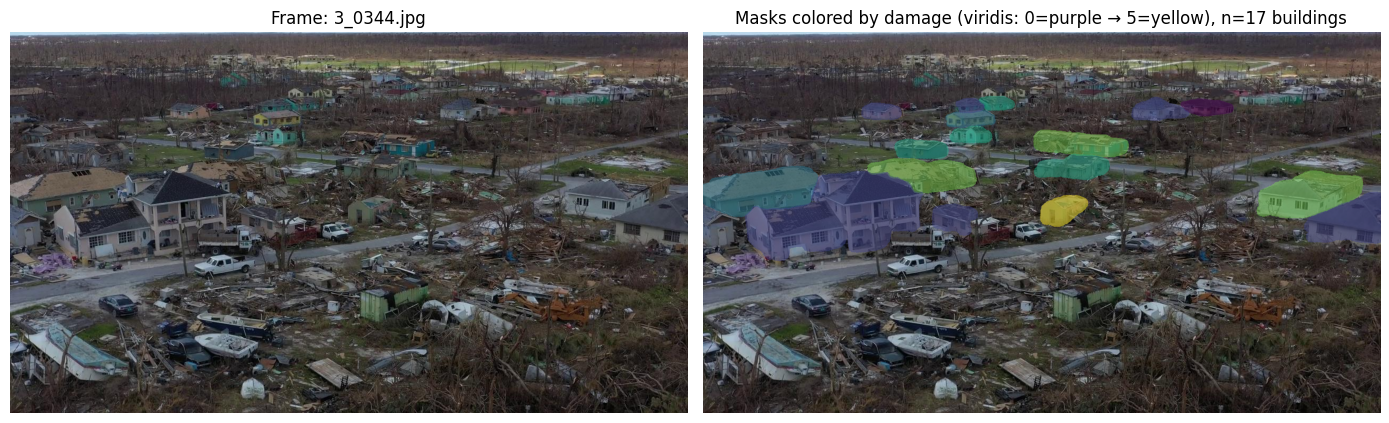

In [12]:
sample_frame = df["frame_name"].value_counts().idxmax()  # frame with most buildings
sample_rows  = df[df["frame_name"] == sample_frame]

base = plt.imread(FRAME_DIR / sample_frame).astype(float) / 255.0
overlay = base.copy()
cmap = plt.cm.viridis

for _, row in sample_rows.iterrows():
    m = plt.imread(MASK_DIR / row["mask_name"])
    if m.ndim == 3: m = m.mean(axis=-1)
    m = m > 127
    color = np.array(cmap(row["damage"] / 5)[:3])
    overlay[m] = 0.5 * overlay[m] + 0.5 * color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(base);    axes[0].set_title(f"Frame: {sample_frame}"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].axis("off")
axes[1].set_title(f"Masks colored by damage (viridis: 0=purple → 5=yellow), n={len(sample_rows)} buildings")
plt.tight_layout(); plt.show()

In [13]:
# One row per building: its modal damage state and instance count
building_summary = (df.groupby("building_id")
                      .agg(modal_damage=("damage", lambda s: s.mode().iloc[0]),
                           n_instances=("damage", "size"))
                      .reset_index())

print("Buildings per modal damage class:")
print(building_summary["modal_damage"].value_counts().sort_index())

# Stratified building-level split: 60% train, 20% val, 20% test
train_bld, temp_bld = train_test_split(
    building_summary, test_size=0.40,
    stratify=building_summary["modal_damage"], random_state=8)
val_bld, test_bld = train_test_split(
    temp_bld, test_size=0.50,
    stratify=temp_bld["modal_damage"], random_state=8)

train_ids = set(train_bld["building_id"])
val_ids   = set(val_bld["building_id"])
test_ids  = set(test_bld["building_id"])

df["split"] = df["building_id"].map(
    lambda b: "train" if b in train_ids else ("val" if b in val_ids else "test")
)

print("\nBuildings and instances per split:")
for s in ["train", "val", "test"]:
    n_b = df.loc[df["split"] == s, "building_id"].nunique()
    n_i = (df["split"] == s).sum()
    print(f"  {s:5s}: {n_b:3d} buildings, {n_i:4d} instances ({100*n_i/len(df):.1f}%)")

print("\nDamage distribution per split (row-normalized):")
print(pd.crosstab(df["split"], df["damage"], normalize="index").round(3))

print("\nRaw damage counts per split:")
print(pd.crosstab(df["split"], df["damage"], margins=True))

Buildings per modal damage class:
modal_damage
0    14
1    27
2    22
3    42
4    28
5    14
Name: count, dtype: int64

Buildings and instances per split:
  train:  88 buildings,  794 instances (54.5%)
  val  :  29 buildings,  315 instances (21.6%)
  test :  30 buildings,  349 instances (23.9%)

Damage distribution per split (row-normalized):
damage      0      1      2      3      4      5
split                                           
test    0.166  0.195  0.163  0.223  0.186  0.066
train   0.105  0.199  0.144  0.312  0.191  0.049
val     0.086  0.121  0.079  0.438  0.130  0.146

Raw damage counts per split:
damage    0    1    2    3    4    5   All
split                                     
test     58   68   57   78   65   23   349
train    83  158  114  248  152   39   794
val      27   38   25  138   41   46   315
All     168  264  196  464  258  108  1458


  processed 50/271 frames
  processed 100/271 frames
  processed 150/271 frames
  processed 200/271 frames
  processed 250/271 frames
  processed 271/271 frames

Patches shape: (1458, 224, 224, 3), dtype: uint8, memory: 219 MB


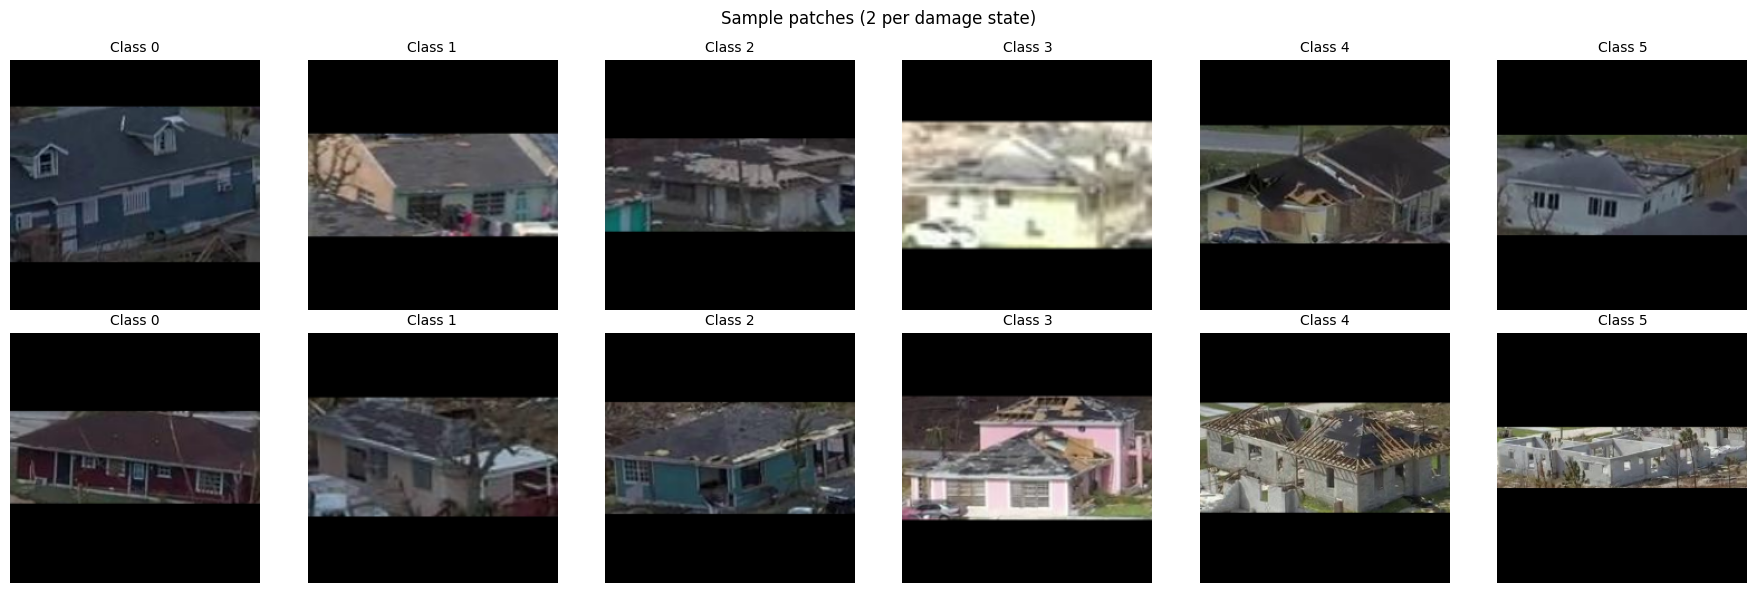

In [14]:
def extract_patch(frame, mask_bool, size=224):
    """Crop frame to mask bbox, pad to square, resize to (size, size). Returns uint8."""
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    r0, r1 = rows[0], rows[-1]
    c0, c1 = cols[0], cols[-1]
    crop = frame[r0:r1+1, c0:c1+1]

    h, w = crop.shape[:2]
    side = max(h, w)
    out = np.zeros((side, side, 3), dtype=np.uint8)
    out[(side - h) // 2 : (side - h) // 2 + h,
        (side - w) // 2 : (side - w) // 2 + w] = crop

    return tf.image.resize(out, (size, size), method="bilinear").numpy().astype(np.uint8)


patches = np.zeros((len(df), 224, 224, 3), dtype=np.uint8)
n_frames = df["frame_name"].nunique()

for i, (fname, group) in enumerate(df.groupby("frame_name")):
    frame = plt.imread(FRAME_DIR / fname)
    for idx, row in group.iterrows():
        mask = plt.imread(MASK_DIR / row["mask_name"])
        mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
        patches[idx] = extract_patch(frame, mb, size=224)
    if (i + 1) % 50 == 0 or i + 1 == n_frames:
        print(f"  processed {i+1}/{n_frames} frames")

print(f"\nPatches shape: {patches.shape}, dtype: {patches.dtype}, "
      f"memory: {patches.nbytes / 1e6:.0f} MB")

# Sanity check: 2 patches per damage class
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for cls in range(6):
    cls_idxs = df[df["damage"] == cls].sample(2, random_state=42).index.tolist()
    for r, ix in enumerate(cls_idxs):
        axes[r, cls].imshow(patches[ix])
        axes[r, cls].set_title(f"Class {cls}", fontsize=10)
        axes[r, cls].axis("off")
plt.suptitle("Sample patches (2 per damage state)")
plt.tight_layout(); plt.show()

Train: X=(794, 224, 224, 3), y=(794,)
Val  : X=(315, 224, 224, 3),   y=(315,)
Test : X=(349, 224, 224, 3),  y=(349,)

Class weights (balanced, train split):
  class 0: weight=1.594, n_train=83
  class 1: weight=0.838, n_train=158
  class 2: weight=1.161, n_train=114
  class 3: weight=0.534, n_train=248
  class 4: weight=0.871, n_train=152
  class 5: weight=3.393, n_train=39


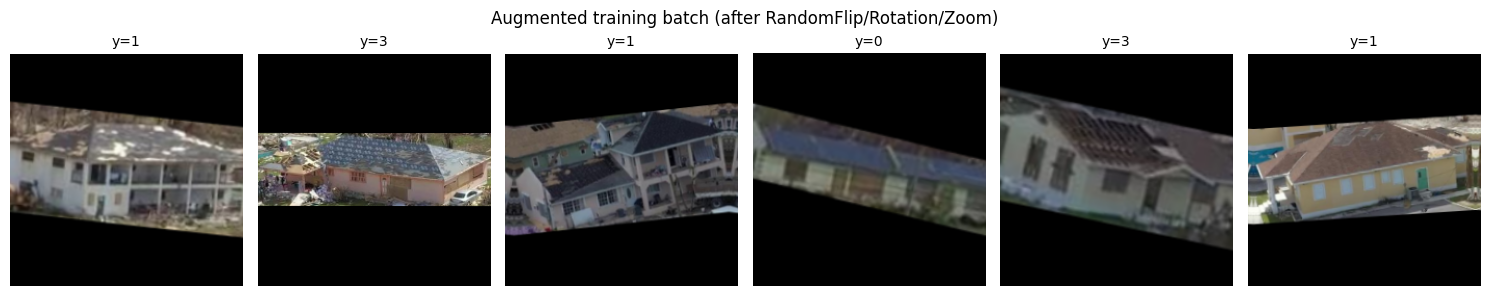

In [15]:
# Index arrays per split
train_idx = df.index[df["split"] == "train"].to_numpy()
val_idx   = df.index[df["split"] == "val"].to_numpy()
test_idx  = df.index[df["split"] == "test"].to_numpy()

X_train, y_train = patches[train_idx], df.loc[train_idx, "damage"].to_numpy()
X_val,   y_val   = patches[val_idx],   df.loc[val_idx,   "damage"].to_numpy()
X_test,  y_test  = patches[test_idx],  df.loc[test_idx,  "damage"].to_numpy()

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val  : X={X_val.shape},   y={y_val.shape}")
print(f"Test : X={X_test.shape},  y={y_test.shape}")

# Augmentation pipeline (training only)
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.04, seed=42),  # ~±15°
    tf.keras.layers.RandomZoom(0.2,   seed=42),
], name="augment")

# tf.data datasets
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=42, reshuffle_each_iteration=True)
            .batch(BATCH)
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

val_ds  = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
           .batch(BATCH).prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
           .batch(BATCH).prefetch(AUTOTUNE))

# Class weights (computed on train only — no leakage)
class_weights = compute_class_weight("balanced", classes=np.arange(6), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights (balanced, train split):")
for cls, w in class_weight_dict.items():
    n = (y_train == cls).sum()
    print(f"  class {cls}: weight={w:.3f}, n_train={n}")

# Sanity check the augmentation visually
batch_x, batch_y = next(iter(train_ds))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(tf.cast(batch_x[i], tf.uint8))
    axes[i].set_title(f"y={batch_y[i].numpy()}", fontsize=10)
    axes[i].axis("off")
plt.suptitle("Augmented training batch (after RandomFlip/Rotation/Zoom)")
plt.tight_layout(); plt.show()

In [16]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ]


# --- Model 1: MLP ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
mlp = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.AveragePooling2D(pool_size=4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="mlp")
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"\n=== MLP ({mlp.count_params():,} params) ===")
hist_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=100,
                    callbacks=make_callbacks(), verbose=2)

# --- Model 2: CNN (no BatchNorm, smaller LR, tighter early stopping) ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="cnn")
cnn.compile(optimizer=tf.keras.optimizers.Adam(3e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"\n=== CNN ({cnn.count_params():,} params) ===")
hist_cnn = cnn.fit(
    train_ds, validation_data=val_ds, epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ],
    verbose=2,
)

# --- Model 3: MobileNetV2, two-step transfer ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
base = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV2 expects [-1, 1]
x = base(x, training=False)                                  # keep BN in inference mode
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv2 = tf.keras.Model(inputs, outputs, name="mobilenetv2")

print(f"\n=== MobileNetV2 — Step 1 (head only, lr=1e-3) ===")
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s1 = mbv2.fit(train_ds, validation_data=val_ds, epochs=25,
                         callbacks=make_callbacks(), verbose=2)

print(f"\n=== MobileNetV2 — Step 2 (full fine-tune, lr=1e-4) ===")
base.trainable = True
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s2 = mbv2.fit(train_ds, validation_data=val_ds, epochs=100,
                         initial_epoch=len(hist_mbv2_s1.history["loss"]),
                         callbacks=make_callbacks(), verbose=2)
hist_mbv2 = {k: hist_mbv2_s1.history[k] + hist_mbv2_s2.history[k] for k in hist_mbv2_s1.history}


=== MLP (2,442,374 params) ===
Epoch 1/100
25/25 - 12s - 480ms/step - accuracy: 0.2128 - loss: 2.6180 - val_accuracy: 0.4032 - val_loss: 1.7513 - learning_rate: 0.0010
Epoch 2/100
25/25 - 6s - 237ms/step - accuracy: 0.2154 - loss: 1.8159 - val_accuracy: 0.4381 - val_loss: 1.7303 - learning_rate: 0.0010
Epoch 3/100
25/25 - 11s - 432ms/step - accuracy: 0.2695 - loss: 1.7671 - val_accuracy: 0.4349 - val_loss: 1.6999 - learning_rate: 0.0010
Epoch 4/100
25/25 - 11s - 420ms/step - accuracy: 0.2821 - loss: 1.7608 - val_accuracy: 0.4381 - val_loss: 1.6932 - learning_rate: 0.0010
Epoch 5/100
25/25 - 6s - 243ms/step - accuracy: 0.3060 - loss: 1.7216 - val_accuracy: 0.4381 - val_loss: 1.7303 - learning_rate: 0.0010
Epoch 6/100
25/25 - 8s - 318ms/step - accuracy: 0.3111 - loss: 1.7141 - val_accuracy: 0.4381 - val_loss: 1.7107 - learning_rate: 0.0010
Epoch 7/100
25/25 - 10s - 390ms/step - accuracy: 0.3123 - loss: 1.6960 - val_accuracy: 0.4381 - val_loss: 1.6993 - learning_rate: 0.0010
Epoch 8/100


Model            Accuracy     ±1 acc   F1 macro
----------------------------------------------
MLP                 0.223      0.573      0.061
CNN                 0.223      0.573      0.061
MobileNetV2         0.404      0.688      0.324


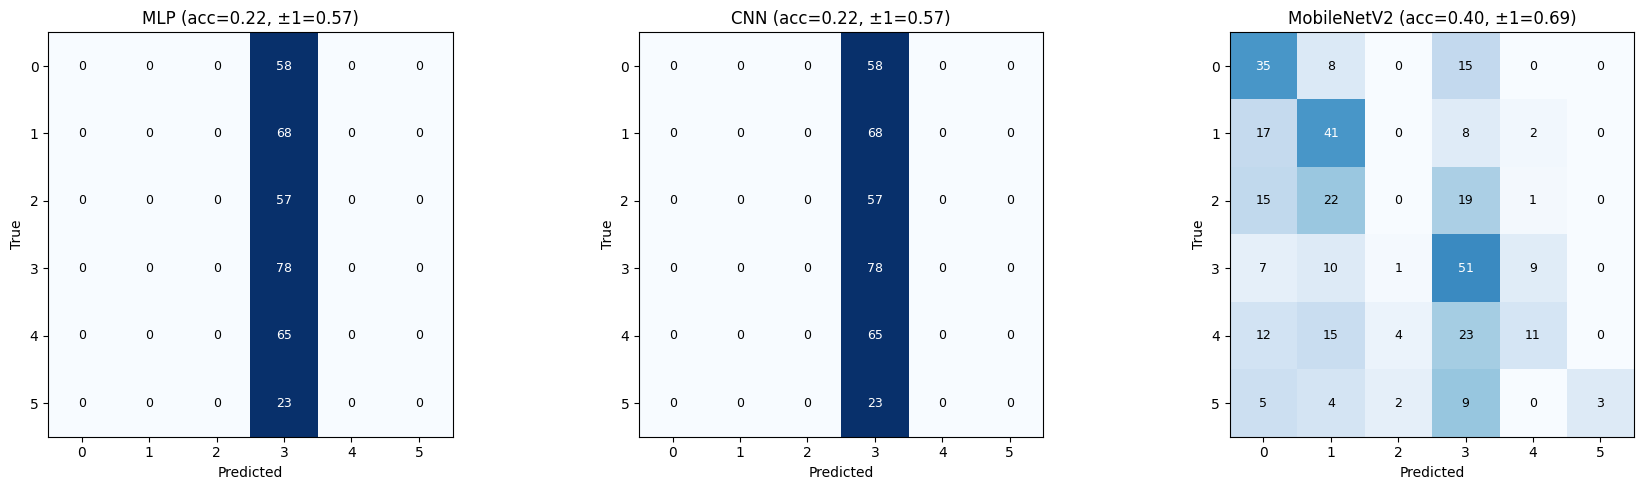


Accuracy stratified by annotation effort:
Model                         Easy            Moderate           Difficult
--------------------------------------------------------------------------
MLP                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
CNN                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
MobileNetV2           0.431 (n=58)       0.379 (n=248)        0.512 (n=43)


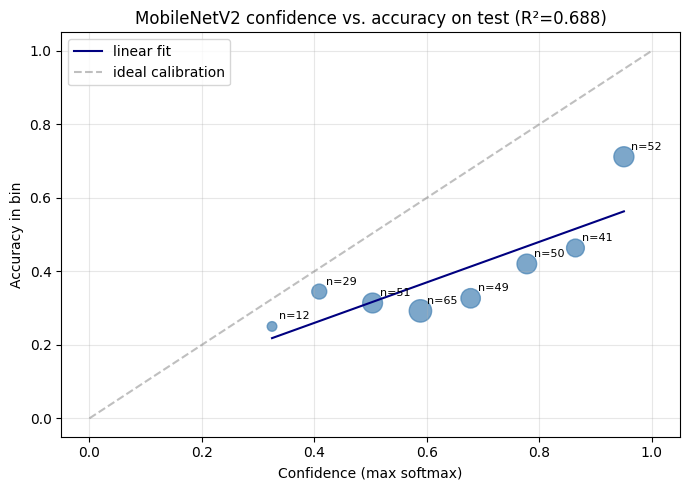


MobileNetV2 confidence-accuracy R² = 0.688
Cheng et al. report R² = 0.896 on Dataset 1 (paper §3.2).


In [17]:
models = {"MLP": mlp, "CNN": cnn, "MobileNetV2": mbv2}
results = {}

for name, model in models.items():
    y_pred_proba = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    results[name] = {
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
        "acc":      accuracy_score(y_test, y_pred),
        "acc_pm1":  np.mean(np.abs(y_test - y_pred) <= 1),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

# Headline metrics table
print(f"{'Model':<14} {'Accuracy':>10} {'±1 acc':>10} {'F1 macro':>10}")
print("-" * 46)
for name, r in results.items():
    print(f"{name:<14} {r['acc']:>10.3f} {r['acc_pm1']:>10.3f} {r['f1_macro']:>10.3f}")

# Confusion matrices, side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"], labels=range(6))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={r['acc']:.2f}, ±1={r['acc_pm1']:.2f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    for i in range(6):
        for j in range(6):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center", color=color, fontsize=9)
plt.tight_layout(); plt.show()

# Accuracy stratified by annotation difficulty
test_effort = df.loc[test_idx, "effort"].to_numpy()
print("\nAccuracy stratified by annotation effort:")
header = f"{'Model':<14}" + "".join(f"{lbl:>20}" for lbl in ["Easy", "Moderate", "Difficult"])
print(header)
print("-" * len(header))
for name, r in results.items():
    cells = []
    for eff in [0, 1, 2]:
        m = test_effort == eff
        cell = f"{accuracy_score(y_test[m], r['y_pred'][m]):.3f} (n={m.sum()})" if m.sum() else "n/a"
        cells.append(cell)
    print(f"{name:<14}" + "".join(f"{c:>20}" for c in cells))

# Confidence vs accuracy — for MobileNetV2 only (the from-scratch models are degenerate)
mbv2_proba = results["MobileNetV2"]["y_pred_proba"]
mbv2_pred  = results["MobileNetV2"]["y_pred"]
confidence = mbv2_proba.max(axis=1)
correct    = (mbv2_pred == y_test).astype(float)

bins = np.linspace(confidence.min(), 1.0, 9)
bin_acc, bin_n, bin_centers = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (confidence >= lo) & (confidence < hi if hi < 1.0 else confidence <= hi)
    if m.sum() > 0:
        bin_acc.append(correct[m].mean())
        bin_n.append(m.sum())
        bin_centers.append(confidence[m].mean())

bin_acc, bin_n, bin_centers = map(np.array, (bin_acc, bin_n, bin_centers))

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bin_centers, bin_acc, s=bin_n * 4, alpha=0.7, color="steelblue")
for x, y, n in zip(bin_centers, bin_acc, bin_n):
    ax.annotate(f"n={n}", (x, y), fontsize=8, xytext=(5, 5), textcoords="offset points")
slope, intercept = np.polyfit(bin_centers, bin_acc, 1)
xs = np.linspace(bin_centers.min(), bin_centers.max(), 50)
ax.plot(xs, slope * xs + intercept, color="navy", label=f"linear fit")
r = np.corrcoef(bin_centers, bin_acc)[0, 1]
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="ideal calibration")
ax.set_xlabel("Confidence (max softmax)"); ax.set_ylabel("Accuracy in bin")
ax.set_title(f"MobileNetV2 confidence vs. accuracy on test (R²={r**2:.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nMobileNetV2 confidence-accuracy R² = {r**2:.3f}")
print(f"Cheng et al. report R² = 0.896 on Dataset 1 (paper §3.2).")